# C2 Parameter Interactions — fixed leaf policies

Leaf-size sweep on SynthACticBench C2 `ackley` with leaf sizes 1–5.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "01_initial":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/c2_parameter_interactions/leaf_policies/01_initial")
OUTPUT_DIRECTORY = HERE / "smac_output"
LEAF_SIZES = (1, 2, 3, 4, 5)
POLICIES = tuple(f"fixed_leaf_{leaf}" for leaf in LEAF_SIZES)
SEEDS = tuple(range(5))
N_TRIALS = 1000
N_INSTANCES = 10
DIMENSION = 10
FUNCTION_NAME = "ackley"
PROBLEM_SEED = 52
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_leaf_{leaf}": f"leaf = {leaf}" for leaf in LEAF_SIZES}
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    expected_leaf = int(policy.rsplit("_", 1)[1])
    for result in runs.values():
        assert result["problem"] == "C2-ParameterInteractions"
        assert result["function_name"] == FUNCTION_NAME
        assert result["dimension"] == DIMENSION
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["deterministic"] is True
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["max_depth"] == 20
        assert result["min_samples_leaf"] == expected_leaf
        assert result["min_samples_split"] == 3
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
print(f"Loaded {sum(map(len, results.values()))}/25 validated trajectories.")

Loaded 25/25 validated trajectories.


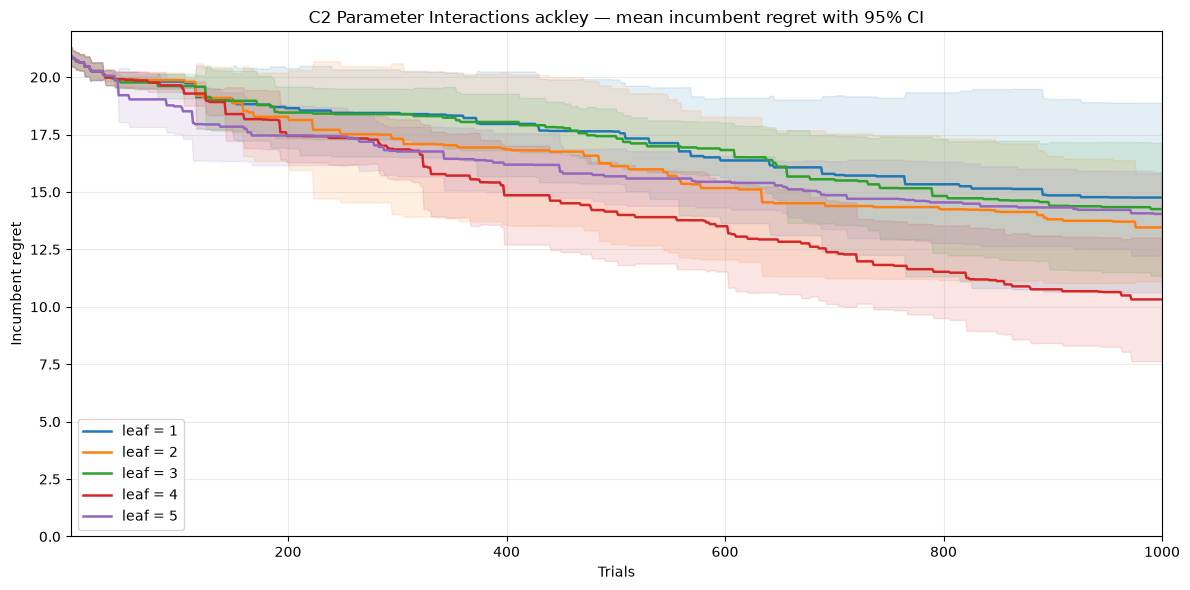

In [3]:
rows = [{"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret} for policy, runs in results.items() for seed, result in runs.items() for iteration, regret in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=1.8)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="C2 Parameter Interactions ackley — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

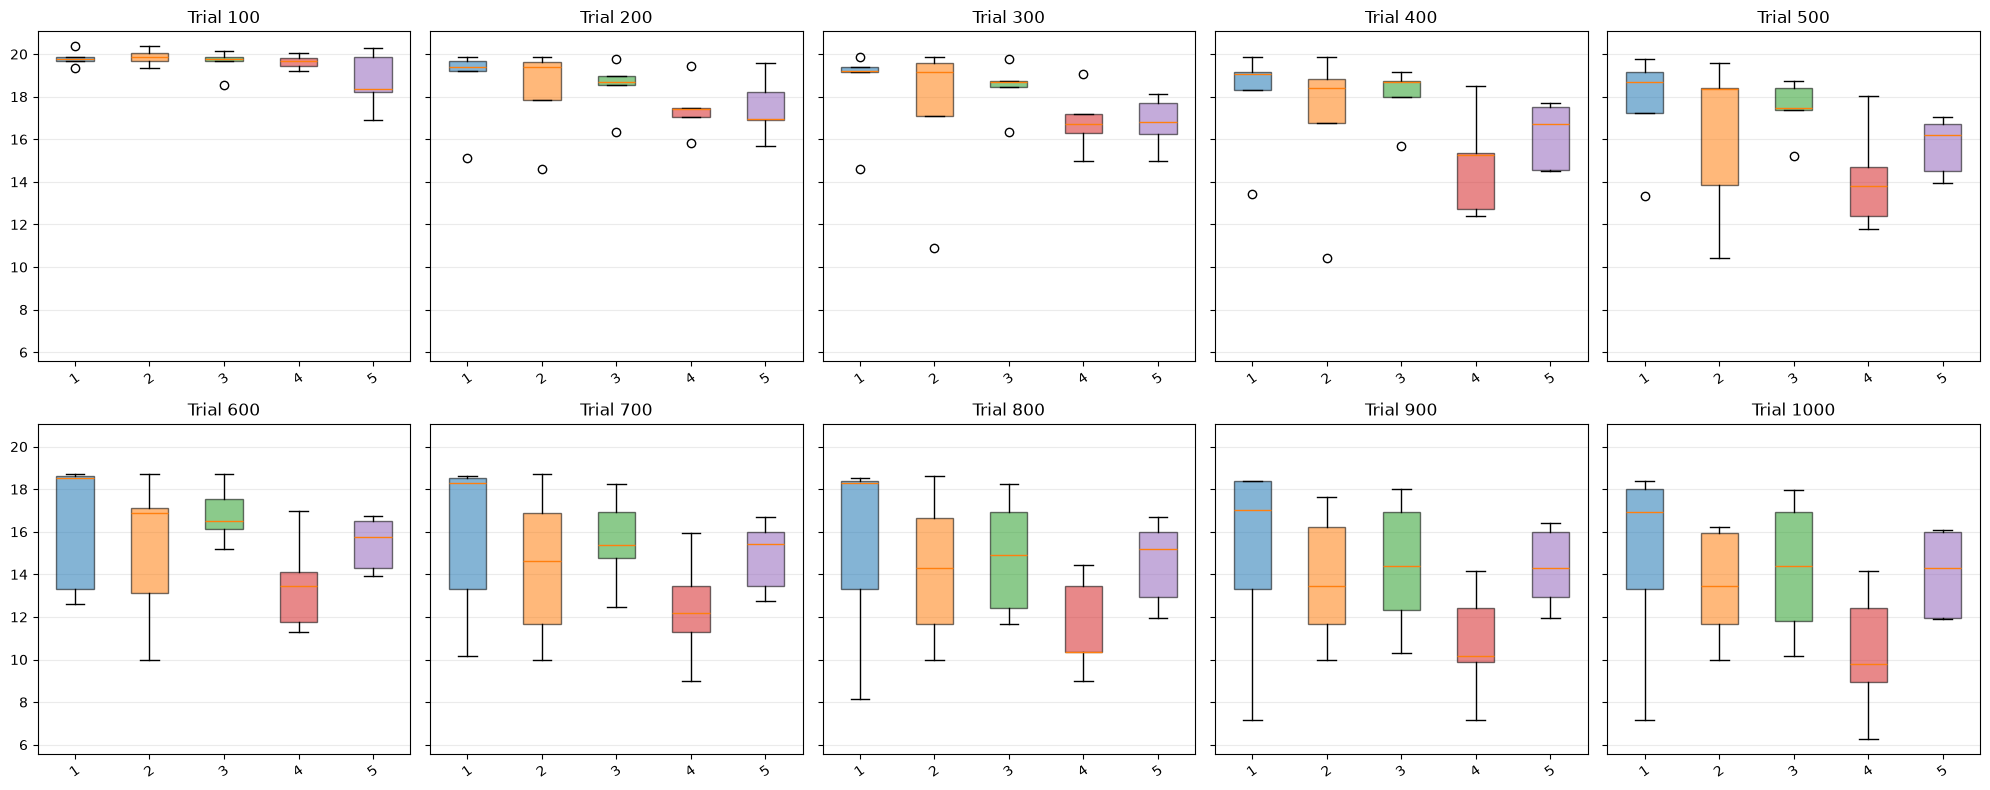

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(leaf) for leaf in LEAF_SIZES])
    for box, policy in zip(boxes["boxes"], POLICIES): box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x", rotation=35); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()

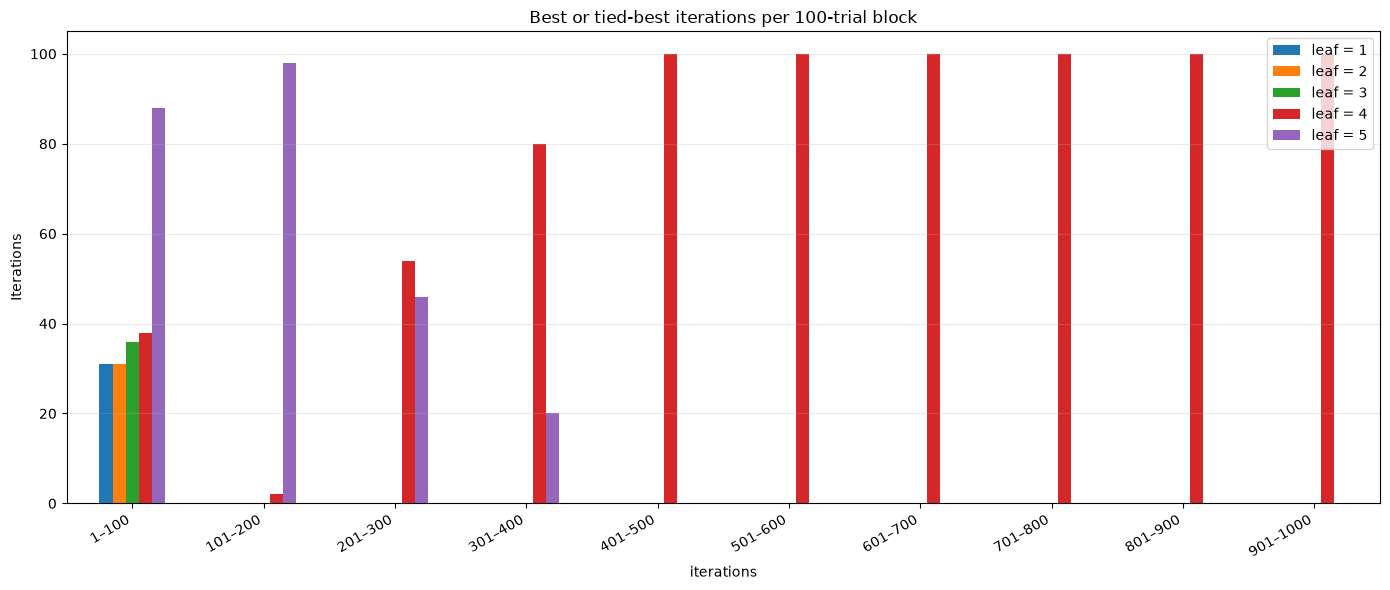

,iterations,superior policy,leaf = 1,leaf = 2,leaf = 3,leaf = 4,leaf = 5
0,1–100,leaf = 5,31,31,36,38,88
1,101–200,leaf = 5,0,0,0,2,98
2,201–300,leaf = 4,0,0,0,54,46
3,301–400,leaf = 4,0,0,0,80,20
4,401–500,leaf = 4,0,0,0,100,0
5,501–600,leaf = 4,0,0,0,100,0
6,601–700,leaf = 4,0,0,0,100,0
7,701–800,leaf = 4,0,0,0,100,0
8,801–900,leaf = 4,0,0,0,100,0
9,901–1000,leaf = 4,0,0,0,100,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum(); maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES}); block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105)); ax.grid(axis="y", alpha=.25); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(block_superiority)

In [6]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                             \
                 mean       std     median        min        max   
policy                                                             
leaf = 4    10.321723  3.070767   9.768759   6.280558  14.162666   
leaf = 2    13.454793  2.686652  13.451958   9.987932  16.212669   
leaf = 5    14.043822  2.074006  14.318673  11.881113  16.106813   
leaf = 3    14.253322  3.305166  14.390371  10.153278  17.967876   
leaf = 1    14.756223  4.704198  16.929873   7.138216  18.393807   

         mean_incumbent_regret                                             
                          mean       std     median        min        max  
policy                                                                     
leaf = 4             14.652770  1.866588  14.716717  12.408471  17.326843  
leaf = 2             16.283086  2.857930  17.184446  11.929874  19.160754  
leaf = 5             16.122374  1.333009  16.728275  14.345926  17.559770  
leaf = 3             17.067875  1.629914  17.102977  14.675237  18.759558  
leaf = 1             17.217416  2.433251  18.898037  14.491281  19.076649

,policy,seed,final_regret,mean_incumbent_regret
19,leaf = 4,0,6.280558,12.408471
9,leaf = 2,0,9.987932,11.929874
14,leaf = 3,0,10.153278,14.675237
24,leaf = 5,0,11.933648,14.345926
4,leaf = 1,0,13.325632,14.491281
18,leaf = 4,1,9.768759,14.716717
13,leaf = 3,1,11.824253,16.447632
23,leaf = 5,1,11.881113,15.127831
8,leaf = 2,1,13.451958,17.184446
3,leaf = 1,1,18.393807,19.005861


In [7]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(checkpoint_table)

mean       std        min     median        max
iteration policy                                                            
100       fixed_leaf_1  19.804664  0.364956  19.364141  19.756521  20.365612
          fixed_leaf_2  19.866452  0.380585  19.364141  19.866295  20.365612
          fixed_leaf_3  19.609315  0.609470  18.567931  19.783475  20.158124
          fixed_leaf_4  19.641976  0.327172  19.206549  19.670751  20.065460
          fixed_leaf_5  18.725225  1.365463  16.882780  18.371222  20.272493
200       fixed_leaf_1  18.645089  1.992994  15.109906  19.382475  19.866295
          fixed_leaf_2  18.268881  2.197555  14.608276  19.389477  19.866295
          fixed_leaf_3  18.457436  1.285155  16.324569  18.668508  19.783475
          fixed_leaf_4  17.437921  1.310695  15.813796  17.436448  19.454349
          fixed_leaf_5  17.457257  1.476698  15.693712  16.940831  19.570701
300       fixed_leaf_1  18.437861  2.166817  14.595129  19.196017  19.866295
          fixed_leaf_2  17.317486  3.746809  10.898621  19.149389  19.866295
          fixed_leaf_3  18.386199  1.264926  16.319478  18.668508  19.774459
          fixed_leaf_4  16.851678  1.495767  14.967534  16.738267  19.080570
          fixed_leaf_5  16.760309  1.234595  14.987152  16.796569  18.106929
400       fixed_leaf_1  17.961833  2.601586  13.411714  19.057708  19.866295
          fixed_leaf_2  16.852101  3.766113  10.420106  18.391764  19.866295
          fixed_leaf_3  18.047372  1.398247  15.665446  18.668508  19.182895
          fixed_leaf_4  14.857044  2.455321  12.412868  15.255388  18.498176
          fixed_leaf_5  16.188246  1.572363  14.488410  16.720762  17.684130
500       fixed_leaf_1  17.628853  2.581823  13.325632  18.684537  19.762742
          fixed_leaf_2  16.123693  3.868154  10.411023  18.355515  19.589738
          fixed_leaf_3  17.429831  1.379064  15.196931  17.448814  18.731557
          fixed_leaf_4  14.145682  2.454192  11.774871  13.817017  18.028635
          fixed_leaf_5  15.679785  1.389421  13.930482  16.208643  17.050627
600       fixed_leaf_1  16.371211  3.114420  12.617115  18.547293  18.735525
          fixed_leaf_2  15.168835  3.550167   9.987932  16.892744  18.735525
          fixed_leaf_3  16.825034  1.353531  15.196931  16.516670  18.731557
          fixed_leaf_4  13.507813  2.254745  11.282602  13.449893  16.961163
          fixed_leaf_5  15.441715  1.274804  13.930482  15.735986  16.720762
700       fixed_leaf_1  15.788140  3.861411  10.159116  18.278168  18.630489
          fixed_leaf_2  14.387829  3.601440   9.987932  14.631207  18.735525
          fixed_leaf_3  15.552367  2.199755  12.453253  15.356217  18.239275
          fixed_leaf_4  12.377469  2.574275   8.998808  12.207049  15.944549
          fixed_leaf_5  14.859781  1.688219  12.750859  15.443215  16.687401
800       fixed_leaf_1  15.334112  4.569053   8.166337  18.278168  18.506615
          fixed_leaf_2  14.242386  3.515355   9.987932  14.276047  18.597889
          fixed_leaf_3  14.824742  2.828892  11.651400  14.894262  18.239275
          fixed_leaf_4  11.524400  2.300139   8.998808  10.374411  14.427070
          fixed_leaf_5  14.543642  2.017644  11.953157  15.171875  16.675246
900       fixed_leaf_1  14.851305  4.783592   7.138216  17.014383  18.393807
          fixed_leaf_2  13.806893  3.153366   9.987932  13.476876  17.636421
          fixed_leaf_3  14.395687  3.169903  10.317614  14.390371  17.992657
          fixed_leaf_4  10.761590  2.671720   7.146136  10.172238  14.162666
          fixed_leaf_5  14.325152  1.919509  11.953157  14.318673  16.435997
1000      fixed_leaf_1  14.756223  4.704198   7.138216  16.929873  18.393807
          fixed_leaf_2  13.454793  2.686652   9.987932  13.451958  16.212669
          fixed_leaf_3  14.253322  3.305166  10.153278  14.390371  17.967876
          fixed_leaf_4  10.321723  3.070767   6.280558   9.768759  14.162666
          fixed_leaf_5  14.043822  2.074006  11.881113  14.318673  16.106813